<a href="https://colab.research.google.com/github/marianacamarotabb/projeto_machine_learning/blob/main/C%C3%B3pia_de_Tentativa3_(retirando_a_coluna_mes).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [457]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [458]:
df_clientes = pd.read_csv("application_record.csv")
df_pagamentos = pd.read_csv("credit_record.csv")

# **Tratamento dos Clientes**

In [459]:
clientes2 = {
    'ID': 'ID_Cliente',
    'CODE_GENDER': 'Genero',
    'FLAG_OWN_CAR': 'Possui_Carro',
    'FLAG_OWN_REALTY': 'Possui_Imovel',
    'CNT_CHILDREN': 'Num_Filhos',
    'AMT_INCOME_TOTAL': 'Renda_Total',
    'NAME_INCOME_TYPE': 'Tipo_Renda',
    'NAME_EDUCATION_TYPE': 'Grau_Escolaridade',
    'NAME_FAMILY_STATUS': 'Status_Familiar',
    'NAME_HOUSING_TYPE': 'Tipo_Moradia',
    'DAYS_BIRTH': 'Dias_Nascimento',
    'DAYS_EMPLOYED': 'Dias_Empregado',
    'FLAG_MOBIL': 'Possui_Celular',
    'FLAG_WORK_PHONE': 'Possui_Telefone_Trabalho',
    'FLAG_PHONE': 'Possui_Telefone',
    'FLAG_EMAIL': 'Possui_Email',
    'OCCUPATION_TYPE': 'Tipo_Ocupacao',
    'CNT_FAM_MEMBERS': 'Num_Membros_Familia',

}
df_clientes = df_clientes.rename(columns=clientes2)

In [607]:
df_clientes.head()

,ID_Cliente,Genero,Possui_Carro,Possui_Imovel,Num_Filhos,Renda_Total,Tipo_Renda,Grau_Escolaridade,Status_Familiar,Tipo_Moradia,Dias_Nascimento,Dias_Empregado,Possui_Celular,Possui_Telefone_Trabalho,Possui_Telefone,Possui_Email,Tipo_Ocupacao,Num_Membros_Familia
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [461]:
df_clientes.shape

(438557, 18)

In [462]:
df_clientes.isnull().sum()

,0
ID_Cliente,0
Genero,0
Possui_Carro,0
Possui_Imovel,0
Num_Filhos,0
Renda_Total,0
Tipo_Renda,0
Grau_Escolaridade,0
Status_Familiar,0
Tipo_Moradia,0


In [463]:
df_clientes["Tipo_Ocupacao"].value_counts()

,count
Tipo_Ocupacao,
Laborers,78240
Core staff,43007
Sales staff,41098
Managers,35487
Drivers,26090
High skill tech staff,17289
Accountants,15985
Medicine staff,13520
Cooking staff,8076


In [464]:
df_clientes['Tipo_Ocupacao'].value_counts(dropna=False)

,count
Tipo_Ocupacao,
NaN,134203
Laborers,78240
Core staff,43007
Sales staff,41098
Managers,35487
Drivers,26090
High skill tech staff,17289
Accountants,15985
Medicine staff,13520


In [465]:
df_clientes_Alterada = df_clientes.copy()
df_clientes_Alterada['Tipo_Ocupacao'] = df_clientes_Alterada['Tipo_Ocupacao'].fillna('Desconhecido')

In [466]:
df_clientes_Alterada.isnull().sum()

,0
ID_Cliente,0
Genero,0
Possui_Carro,0
Possui_Imovel,0
Num_Filhos,0
Renda_Total,0
Tipo_Renda,0
Grau_Escolaridade,0
Status_Familiar,0
Tipo_Moradia,0


In [467]:
df_clientes_Alterada.head(100)

,ID_Cliente,Genero,Possui_Carro,Possui_Imovel,Num_Filhos,Renda_Total,Tipo_Renda,Grau_Escolaridade,Status_Familiar,Tipo_Moradia,Dias_Nascimento,Dias_Empregado,Possui_Celular,Possui_Telefone_Trabalho,Possui_Telefone,Possui_Email,Tipo_Ocupacao,Num_Membros_Familia
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Desconhecido,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Desconhecido,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,5008905,F,N,Y,0,297000.0,Commercial associate,Secondary / secondary special,Single / not married,Rented apartment,-15519,-3234,1,0,0,0,Laborers,1.0
96,5008906,F,N,Y,0,297000.0,Commercial associate,Secondary / secondary special,Single / not married,Rented apartment,-15519,-3234,1,0,0,0,Laborers,1.0
97,5008907,F,N,Y,0,297000.0,Commercial associate,Secondary / secondary special,Single / not married,Rented apartment,-15519,-3234,1,0,0,0,Laborers,1.0
98,5008908,F,N,Y,0,297000.0,Commercial associate,Secondary / secondary special,Single / not married,Rented apartment,-15519,-3234,1,0,0,0,Laborers,1.0


In [468]:
df_clientes_Alterada.shape

(438557, 18)

In [469]:
df_clientes_Alterada.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID_Cliente                438557 non-null  int64  
 1   Genero                    438557 non-null  object 
 2   Possui_Carro              438557 non-null  object 
 3   Possui_Imovel             438557 non-null  object 
 4   Num_Filhos                438557 non-null  int64  
 5   Renda_Total               438557 non-null  float64
 6   Tipo_Renda                438557 non-null  object 
 7   Grau_Escolaridade         438557 non-null  object 
 8   Status_Familiar           438557 non-null  object 
 9   Tipo_Moradia              438557 non-null  object 
 10  Dias_Nascimento           438557 non-null  int64  
 11  Dias_Empregado            438557 non-null  int64  
 12  Possui_Celular            438557 non-null  int64  
 13  Possui_Telefone_Trabalho  438557 non-null  i

In [470]:
df_clientes_Alterada.duplicated().sum()

np.int64(0)

# **Tratamento dos Pagamentos**

In [471]:
pagamentos2 = {
    'ID': 'ID_Cliente',
    'MONTHS_BALANCE': 'Meses_Balanco',
    'STATUS': 'Status_Pagamento'}
df_pagamentos = df_pagamentos.rename(columns=pagamentos2)

In [605]:
df_pagamentos.head(100)

,ID_Cliente,Meses_Balanco,Status_Pagamento,Status
0,5001711,0,X,0
1,5001711,-1,0,0
2,5001711,-2,0,0
3,5001711,-3,0,0
4,5001712,0,C,0
...,...,...,...,...
95,5001715,-35,X,0
96,5001715,-36,X,0
97,5001715,-37,X,0
98,5001715,-38,X,0


In [473]:
df_pagamentos['Status_Pagamento'].unique()

array(['X', '0', 'C', '1', '2', '3', '4', '5'], dtype=object)

In [606]:
df_pagamentos.shape

(1048575, 4)

In [475]:
df_pagamentos.isnull().sum()

,0
ID_Cliente,0
Meses_Balanco,0
Status_Pagamento,0


In [476]:
df_pagamentos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   ID_Cliente        1048575 non-null  int64 
 1   Meses_Balanco     1048575 non-null  int64 
 2   Status_Pagamento  1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [477]:
df_pagamentos.duplicated().sum()

np.int64(0)

In [478]:
df_pagamentos["Status_Pagamento"].value_counts()

,count
Status_Pagamento,
C,442031
0,383120
X,209230
1,11090
5,1693
2,868
3,320
4,223


In [479]:
df_pagamentos["ID_Cliente"].value_counts()

,count
ID_Cliente,
5016338,61
5090968,61
5095366,61
5122274,61
5045615,61
...,...
5012689,1
5012728,1
5016441,1


In [480]:
df_pagamentos["Meses_Balanco"].value_counts()

,count
Meses_Balanco,
-1,34436
-2,34209
0,33856
-3,33854
-4,33365
...,...
-56,2109
-57,1649
-58,1255


In [481]:
df_pagamentos['Meses_Balanco'].unique()

array([  0,  -1,  -2,  -3,  -4,  -5,  -6,  -7,  -8,  -9, -10, -11, -12,
       -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25,
       -26, -27, -28, -29, -30, -31, -32, -33, -34, -35, -36, -37, -38,
       -39, -40, -41, -42, -43, -44, -45, -46, -47, -48, -49, -50, -51,
       -52, -53, -54, -55, -56, -57, -58, -59, -60])

# coluna Status com:

# 0 = pagou (C)
# 1 = não pagou ou atrasou (0, 1, 2, 3, 4, 5)
# NaN = não possui histórico de crédito (X)


0 Atraso de 1 a 29 dias

1	Atraso de 30 a 59 dias

2	Atraso de 60 a 89 dias

3	Atraso de 90 a 119 dias

4	Atraso de 120 a 149 dias

5	Atraso superior a 150 dias, dívida em cobrança ou baixada como prejuízo

C	Empréstimo/financiamento quitado naquele mês

X	Não havia empréstimo naquele mêsInterpretação de risco

Do menor para o maior risco de inadimplência:

X → C → 0 → 1 → 2 → 3 → 4 → 5

X: sem empréstimo ativo.
C: empréstimo quitado.
0 a 5: níveis crescentes de atraso.
5: situação mais crítica, indicando inadimplência severa ou prejuízo para a instituição financeira.

In [482]:
df_pagamentos['Status_Pagamento'].unique()

array(['X', '0', 'C', '1', '2', '3', '4', '5'], dtype=object)

In [483]:
df_pagamentos['Status'] = df_pagamentos['Status_Pagamento'].map({'C': 0, 'X': 0, '0': 0, '1': 1, '2': 1, '3': 1, '4': 1, '5': 1})

In [484]:
df_pagamentos[['Status_Pagamento', 'Status']].head(100)

,Status_Pagamento,Status
0,X,0
1,0,0
2,0,0
3,0,0
4,C,0
...,...,...
95,X,0
96,X,0
97,X,0
98,X,0


In [485]:
df_pagamentos["Status"].value_counts(dropna=False)

,count
Status,
0,1034381
1,14194


In [486]:
df_pagamentos.head(100)

,ID_Cliente,Meses_Balanco,Status_Pagamento,Status
0,5001711,0,X,0
1,5001711,-1,0,0
2,5001711,-2,0,0
3,5001711,-3,0,0
4,5001712,0,C,0
...,...,...,...,...
95,5001715,-35,X,0
96,5001715,-36,X,0
97,5001715,-37,X,0
98,5001715,-38,X,0


In [487]:
df_pagamentos.shape

(1048575, 4)

In [488]:
df_pagamentos.isnull().sum()

,0
ID_Cliente,0
Meses_Balanco,0
Status_Pagamento,0
Status,0


#calculo antes de excluir os 209230 (X)

In [489]:
df_pagamentos = df_pagamentos.dropna(subset=['Status'])

In [490]:
df_pagamentos.isnull().sum()

,0
ID_Cliente,0
Meses_Balanco,0
Status_Pagamento,0
Status,0


In [491]:
df_pagamentos.tail(3)

,ID_Cliente,Meses_Balanco,Status_Pagamento,Status
1048572,5150487,-27,C,0
1048573,5150487,-28,C,0
1048574,5150487,-29,C,0


In [492]:
df_pagamentos['Status'].unique()

array([0, 1])

In [493]:
df_pagamentos['Status'].value_counts()

,count
Status,
0,1034381
1,14194


# 1048575 - 209230 (X) = 839345

In [494]:
df_pagamentos.shape

(1048575, 4)

In [495]:
df_analise = df_pagamentos.groupby('ID_Cliente').agg(

meses_observados=('Meses_Balanco', 'count'),
qtde_atrasos=('Status', 'sum'),
perc_atrasos=('Status', 'mean')
).reset_index()

In [496]:
df_analise.head(100)

,ID_Cliente,meses_observados,qtde_atrasos,perc_atrasos
0,5001711,4,0,0.0
1,5001712,19,0,0.0
2,5001713,22,0,0.0
3,5001714,15,0,0.0
4,5001715,60,0,0.0
...,...,...,...,...
95,5001837,58,0,0.0
96,5001838,39,0,0.0
97,5001839,16,0,0.0
98,5001840,20,0,0.0


In [497]:
df_analise['qtde_atrasos'].value_counts()

,count
qtde_atrasos,
0,40635
1,2766
2,1094
3,507
4,282
5,177
6,114
7,86
8,62


In [498]:
df_analise['perc_atrasos'].value_counts()

,count
perc_atrasos,
0.000000,40635
0.125000,153
0.166667,136
0.083333,136
0.142857,136
...,...
0.772727,1
0.818182,1
0.687500,1


In [499]:
df_analise.shape

(45985, 4)

quantidade de clentes 41449


# Unificação da base de clientes com a de Pagamento considerando os clientes que teve operações realizadas nos ultimos 60 meses

In [500]:
df_clientes_Alterada['ID_Cliente'].nunique()

438510

In [501]:
df_analise['ID_Cliente'].nunique()

45985

In [502]:
df_clientes_pagamentos = pd.merge(
    df_clientes_Alterada,
    df_analise,
    on="ID_Cliente", how='inner')

In [503]:
df_clientes_pagamentos['ID_Cliente'].nunique()

36457

In [504]:
df_clientes_pagamentos

,ID_Cliente,Genero,Possui_Carro,Possui_Imovel,Num_Filhos,Renda_Total,Tipo_Renda,Grau_Escolaridade,Status_Familiar,Tipo_Moradia,...,Dias_Empregado,Possui_Celular,Possui_Telefone_Trabalho,Possui_Telefone,Possui_Email,Tipo_Ocupacao,Num_Membros_Familia,meses_observados,qtde_atrasos,perc_atrasos
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,Desconhecido,2.0,16,1,0.062500
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,Desconhecido,2.0,15,1,0.066667
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,-1134,1,0,0,0,Security staff,2.0,30,0,0.000000
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,-3051,1,0,1,1,Sales staff,1.0,5,0,0.000000
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,-3051,1,0,1,1,Sales staff,1.0,5,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,M,Y,Y,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,...,-2420,1,0,0,0,Managers,2.0,12,4,0.333333
36453,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,House / apartment,...,-1325,1,0,1,1,Medicine staff,2.0,24,18,0.750000
36454,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,...,-1325,1,0,1,1,Medicine staff,2.0,33,18,0.545455
36455,5150049,F,N,Y,0,283500.0,Working,Secondary / secondary special,Married,House / apartment,...,-655,1,0,0,0,Sales staff,2.0,10,2,0.200000


In [505]:
df_clientes_pagamentos = df_clientes_pagamentos.drop_duplicates(subset='ID_Cliente')

In [506]:
df_clientes_pagamentos.shape

(36457, 21)

In [507]:
df_clientes_pagamentos.isnull().sum()

,0
ID_Cliente,0
Genero,0
Possui_Carro,0
Possui_Imovel,0
Num_Filhos,0
Renda_Total,0
Tipo_Renda,0
Grau_Escolaridade,0
Status_Familiar,0
Tipo_Moradia,0


In [508]:
df_clientes_pagamentos['target'] = (df_clientes_pagamentos['perc_atrasos'] > 0).astype(int)

In [509]:
df_clientes_pagamentos.head(5)

,ID_Cliente,Genero,Possui_Carro,Possui_Imovel,Num_Filhos,Renda_Total,Tipo_Renda,Grau_Escolaridade,Status_Familiar,Tipo_Moradia,...,Possui_Celular,Possui_Telefone_Trabalho,Possui_Telefone,Possui_Email,Tipo_Ocupacao,Num_Membros_Familia,meses_observados,qtde_atrasos,perc_atrasos,target
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Desconhecido,2.0,16,1,0.062500,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Desconhecido,2.0,15,1,0.066667,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,1,0,0,0,Security staff,2.0,30,0,0.000000,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,0,1,1,Sales staff,1.0,5,0,0.000000,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,0,1,1,Sales staff,1.0,5,0,0.000000,0


In [510]:
df_clientes_pagamentos['target'].value_counts()

,count
target,
0,32166
1,4291


In [511]:
df_clientes_pagamentos.shape

(36457, 22)

In [512]:
df_clientes_pagamentos.isnull().sum()

,0
ID_Cliente,0
Genero,0
Possui_Carro,0
Possui_Imovel,0
Num_Filhos,0
Renda_Total,0
Tipo_Renda,0
Grau_Escolaridade,0
Status_Familiar,0
Tipo_Moradia,0


In [513]:
df_clientes_pagamentos.describe().T

,count,mean,std,min,25%,50%,75%,max
ID_Cliente,36457.0,5.078227e+06,41875.240788,5008804.0,5042028.0,5074614.0,5115396.0,5150487.0
Num_Filhos,36457.0,4.303152e-01,0.742367,0.0,0.0,0.0,1.0,19.0
Renda_Total,36457.0,1.866857e+05,101789.226482,27000.0,121500.0,157500.0,225000.0,1575000.0
Dias_Nascimento,36457.0,-1.597517e+04,4200.549944,-25152.0,-19438.0,-15563.0,-12462.0,-7489.0
Dias_Empregado,36457.0,5.926294e+04,137651.334859,-15713.0,-3153.0,-1552.0,-408.0,365243.0
Possui_Celular,36457.0,1.000000e+00,0.000000,1.0,1.0,1.0,1.0,1.0
Possui_Telefone_Trabalho,36457.0,2.255260e-01,0.417934,0.0,0.0,0.0,0.0,1.0
Possui_Telefone,36457.0,2.948131e-01,0.455965,0.0,0.0,0.0,1.0,1.0
Possui_Email,36457.0,8.972214e-02,0.285787,0.0,0.0,0.0,0.0,1.0
Num_Membros_Familia,36457.0,2.198453e+00,0.911686,1.0,2.0,2.0,3.0,20.0


*
*
*
*


### **Transformação variáveis Categorias em númericas**
































In [514]:
from sklearn.preprocessing import LabelEncoder


In [515]:
set(df_clientes_pagamentos["Genero"])

{'F', 'M'}

In [516]:
set(df_clientes_pagamentos['Possui_Imovel'])

{'N', 'Y'}

In [517]:
set(df_clientes_pagamentos['Possui_Carro'])

{'N', 'Y'}

In [518]:
Colunas = ['Genero', 'Possui_Imovel', 'Possui_Carro']
LabelEncoder_X = LabelEncoder()
for col in Colunas:
    df_clientes_pagamentos[col] = LabelEncoder_X.fit_transform(df_clientes_pagamentos[col])

**Genero**- M=1 e F=0

***Possui_Carro*** - Y=1 e N=0

**Possui_Imovel** - Y=1 e N=0

In [519]:
df_clientes_pagamentos.head(5)

,ID_Cliente,Genero,Possui_Carro,Possui_Imovel,Num_Filhos,Renda_Total,Tipo_Renda,Grau_Escolaridade,Status_Familiar,Tipo_Moradia,...,Possui_Celular,Possui_Telefone_Trabalho,Possui_Telefone,Possui_Email,Tipo_Ocupacao,Num_Membros_Familia,meses_observados,qtde_atrasos,perc_atrasos,target
0,5008804,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Desconhecido,2.0,16,1,0.062500,1
1,5008805,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Desconhecido,2.0,15,1,0.066667,1
2,5008806,1,1,1,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,1,0,0,0,Security staff,2.0,30,0,0.000000,0
3,5008808,0,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,0,1,1,Sales staff,1.0,5,0,0.000000,0
4,5008809,0,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,0,1,1,Sales staff,1.0,5,0,0.000000,0


Tranforfoemação da variáveis que possuem mais de dois itens por coluna

Tipo_Renda / Grau_Escolaridade / Status_Familiar /Tipo_Moradia / Tipo_Ocupação


In [520]:
dummy_Tipo_Renda = pd.get_dummies(df_clientes_pagamentos['Tipo_Renda'], prefix='dummyRenda')
dummy_Grau_Escolaridade = pd.get_dummies(df_clientes_pagamentos['Grau_Escolaridade'], prefix='dummyEscolaridade')
dummy_Status_Familiar = pd.get_dummies(df_clientes_pagamentos['Status_Familiar'], prefix='dummyFamiliar')
dummy_Tipo_Moradia = pd.get_dummies(df_clientes_pagamentos['Tipo_Moradia'], prefix='dummyMoradia')
dummy_Tipo_Ocupacao = pd.get_dummies(df_clientes_pagamentos['Tipo_Ocupacao'], prefix='dummyOcupaca')

In [521]:
df_clientes_pagamentos_dummy = pd.concat([df_clientes_pagamentos, dummy_Tipo_Renda, dummy_Grau_Escolaridade, dummy_Status_Familiar, dummy_Tipo_Moradia, dummy_Tipo_Ocupacao], axis=1)

In [522]:
bool_cols = df_clientes_pagamentos_dummy.select_dtypes(include='bool').columns
df_clientes_pagamentos_dummy[bool_cols] = (df_clientes_pagamentos_dummy[bool_cols].astype(int))

In [523]:
df_clientes_pagamentos_dummy.head(100)


,ID_Cliente,Genero,Possui_Carro,Possui_Imovel,Num_Filhos,Renda_Total,Tipo_Renda,Grau_Escolaridade,Status_Familiar,Tipo_Moradia,...,dummyOcupaca_Laborers,dummyOcupaca_Low-skill Laborers,dummyOcupaca_Managers,dummyOcupaca_Medicine staff,dummyOcupaca_Private service staff,dummyOcupaca_Realty agents,dummyOcupaca_Sales staff,dummyOcupaca_Secretaries,dummyOcupaca_Security staff,dummyOcupaca_Waiters/barmen staff
0,5008804,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,0,0,0,0,0,0,0,0,0,0
1,5008805,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,0,0,0,0,0,0,0,0,0,0
2,5008806,1,1,1,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,0,0,0,0,0,0,0,0,1,0
3,5008808,0,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,0,0,0,0,0,0,1,0,0,0
4,5008809,0,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,5008912,0,0,1,0,297000.0,Commercial associate,Secondary / secondary special,Single / not married,Rented apartment,...,1,0,0,0,0,0,0,0,0,0
96,5008913,0,0,1,0,297000.0,Commercial associate,Secondary / secondary special,Single / not married,Rented apartment,...,1,0,0,0,0,0,0,0,0,0
97,5008914,0,0,1,0,297000.0,Commercial associate,Secondary / secondary special,Single / not married,Rented apartment,...,1,0,0,0,0,0,0,0,0,0
98,5008915,0,0,1,0,297000.0,Commercial associate,Secondary / secondary special,Single / not married,Rented apartment,...,1,0,0,0,0,0,0,0,0,0


In [524]:
df = df_clientes_pagamentos_dummy

In [525]:
df.head(100)

,ID_Cliente,Genero,Possui_Carro,Possui_Imovel,Num_Filhos,Renda_Total,Tipo_Renda,Grau_Escolaridade,Status_Familiar,Tipo_Moradia,...,dummyOcupaca_Laborers,dummyOcupaca_Low-skill Laborers,dummyOcupaca_Managers,dummyOcupaca_Medicine staff,dummyOcupaca_Private service staff,dummyOcupaca_Realty agents,dummyOcupaca_Sales staff,dummyOcupaca_Secretaries,dummyOcupaca_Security staff,dummyOcupaca_Waiters/barmen staff
0,5008804,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,0,0,0,0,0,0,0,0,0,0
1,5008805,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,0,0,0,0,0,0,0,0,0,0
2,5008806,1,1,1,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,0,0,0,0,0,0,0,0,1,0
3,5008808,0,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,0,0,0,0,0,0,1,0,0,0
4,5008809,0,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,5008912,0,0,1,0,297000.0,Commercial associate,Secondary / secondary special,Single / not married,Rented apartment,...,1,0,0,0,0,0,0,0,0,0
96,5008913,0,0,1,0,297000.0,Commercial associate,Secondary / secondary special,Single / not married,Rented apartment,...,1,0,0,0,0,0,0,0,0,0
97,5008914,0,0,1,0,297000.0,Commercial associate,Secondary / secondary special,Single / not married,Rented apartment,...,1,0,0,0,0,0,0,0,0,0
98,5008915,0,0,1,0,297000.0,Commercial associate,Secondary / secondary special,Single / not married,Rented apartment,...,1,0,0,0,0,0,0,0,0,0


In [526]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 62 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   ID_Cliente                                       36457 non-null  int64  
 1   Genero                                           36457 non-null  int64  
 2   Possui_Carro                                     36457 non-null  int64  
 3   Possui_Imovel                                    36457 non-null  int64  
 4   Num_Filhos                                       36457 non-null  int64  
 5   Renda_Total                                      36457 non-null  float64
 6   Tipo_Renda                                       36457 non-null  object 
 7   Grau_Escolaridade                                36457 non-null  object 
 8   Status_Familiar                                  36457 non-null  object 
 9   Tipo_Moradia                

In [527]:
df.shape

(36457, 62)

### #remover as colunas categóricas originais para evitar duplicidade de informação:

In [528]:
df= df.drop(columns=['Tipo_Renda', 'Grau_Escolaridade', 'Status_Familiar', 'Tipo_Moradia', 'Tipo_Ocupacao'])


In [529]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 57 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   ID_Cliente                                       36457 non-null  int64  
 1   Genero                                           36457 non-null  int64  
 2   Possui_Carro                                     36457 non-null  int64  
 3   Possui_Imovel                                    36457 non-null  int64  
 4   Num_Filhos                                       36457 non-null  int64  
 5   Renda_Total                                      36457 non-null  float64
 6   Dias_Nascimento                                  36457 non-null  int64  
 7   Dias_Empregado                                   36457 non-null  int64  
 8   Possui_Celular                                   36457 non-null  int64  
 9   Possui_Telefone_Trabalho    

In [530]:
df.shape

(36457, 57)

A variável/coluna **Possui_Celular** não traz informação, pois é igual para todos os clientes.

In [531]:
df['Possui_Celular'].unique()

array([1])

In [532]:
df = df.drop(columns=['Possui_Celular'])

*
*
*
*
*
*
*
*
*
## **Correlação**

In [533]:
corr = df.corr()

corr

,ID_Cliente,Genero,Possui_Carro,Possui_Imovel,Num_Filhos,Renda_Total,Dias_Nascimento,Dias_Empregado,Possui_Telefone_Trabalho,Possui_Telefone,...,dummyOcupaca_Laborers,dummyOcupaca_Low-skill Laborers,dummyOcupaca_Managers,dummyOcupaca_Medicine staff,dummyOcupaca_Private service staff,dummyOcupaca_Realty agents,dummyOcupaca_Sales staff,dummyOcupaca_Secretaries,dummyOcupaca_Security staff,dummyOcupaca_Waiters/barmen staff
ID_Cliente,1.000000,0.012022,-0.011163,-0.098851,0.028878,-0.017667,0.056016,-0.038043,0.079215,0.009879,...,0.000148,0.008097,-0.002743,0.014370,0.014616,0.012489,0.007745,0.006347,0.005772,0.035343
Genero,0.012022,1.000000,0.361379,-0.050758,0.077690,0.197805,0.202352,-0.173434,0.064994,-0.026833,...,0.240526,0.067752,0.093315,-0.115488,-0.053998,-0.020151,-0.133468,-0.040708,0.102794,-0.024041
Possui_Carro,-0.011163,0.361379,1.000000,-0.015185,0.105839,0.215506,0.157144,-0.156452,0.021644,-0.014019,...,0.033320,-0.020810,0.116675,-0.040532,-0.013808,-0.004858,-0.031771,-0.026697,-0.008401,-0.032859
Possui_Imovel,-0.098851,-0.050758,-0.015185,1.000000,-0.000575,0.032719,-0.129838,0.093006,-0.207732,-0.066601,...,-0.025019,-0.003072,0.002837,-0.008927,0.013761,0.009924,-0.012238,-0.005005,-0.004594,0.008512
Num_Filhos,0.028878,0.077690,0.105839,-0.000575,1.000000,0.033691,0.339357,-0.229379,0.048091,-0.016291,...,0.037378,0.000906,0.047228,0.002191,0.004958,0.004772,0.041262,0.009218,-0.004896,0.010789
Renda_Total,-0.017667,0.197805,0.215506,0.032719,0.033691,1.000000,0.067908,-0.168611,-0.037746,0.017245,...,-0.030680,-0.036002,0.272512,-0.037397,0.011677,0.027842,-0.037372,-0.011789,-0.012178,-0.020736
Dias_Nascimento,0.056016,0.202352,0.157144,-0.129838,0.339357,0.067908,1.000000,-0.616213,0.179054,-0.028659,...,0.145276,0.014315,0.054658,0.004301,0.018760,0.010206,0.151254,0.010768,-0.023114,0.042869
Dias_Empregado,-0.038043,-0.173434,-0.156452,0.093006,-0.229379,-0.168611,-0.616213,1.000000,-0.242869,-0.007233,...,-0.204054,-0.031023,-0.135422,-0.085357,-0.044123,-0.021001,-0.144442,-0.028989,-0.057027,-0.030672
Possui_Telefone_Trabalho,0.079215,0.064994,0.021644,-0.207732,0.048091,-0.037746,0.179054,-0.242869,1.000000,0.311644,...,0.039674,0.023296,0.042367,0.007993,-0.001073,-0.001153,0.029920,0.007098,0.004927,0.025482
Possui_Telefone,0.009879,-0.026833,-0.014019,-0.066601,-0.016291,0.017245,-0.028659,-0.007233,0.311644,1.000000,...,-0.031696,0.002966,0.002627,-0.009697,0.010942,0.004799,0.007483,0.003263,-0.025478,-0.004624


In [534]:
import seaborn as sns
import matplotlib.pyplot as plt

In [535]:
corr_alvo = df.corr()['target'].sort_values(ascending=False)

corr_alvo

,target
target,1.000000
perc_atrasos,0.664331
qtde_atrasos,0.567493
meses_observados,0.102934
Dias_Nascimento,0.028943
Renda_Total,0.024202
Genero,0.021257
Possui_Email,0.019658
dummyEscolaridade_Incomplete higher,0.018118
dummyRenda_Commercial associate,0.016257


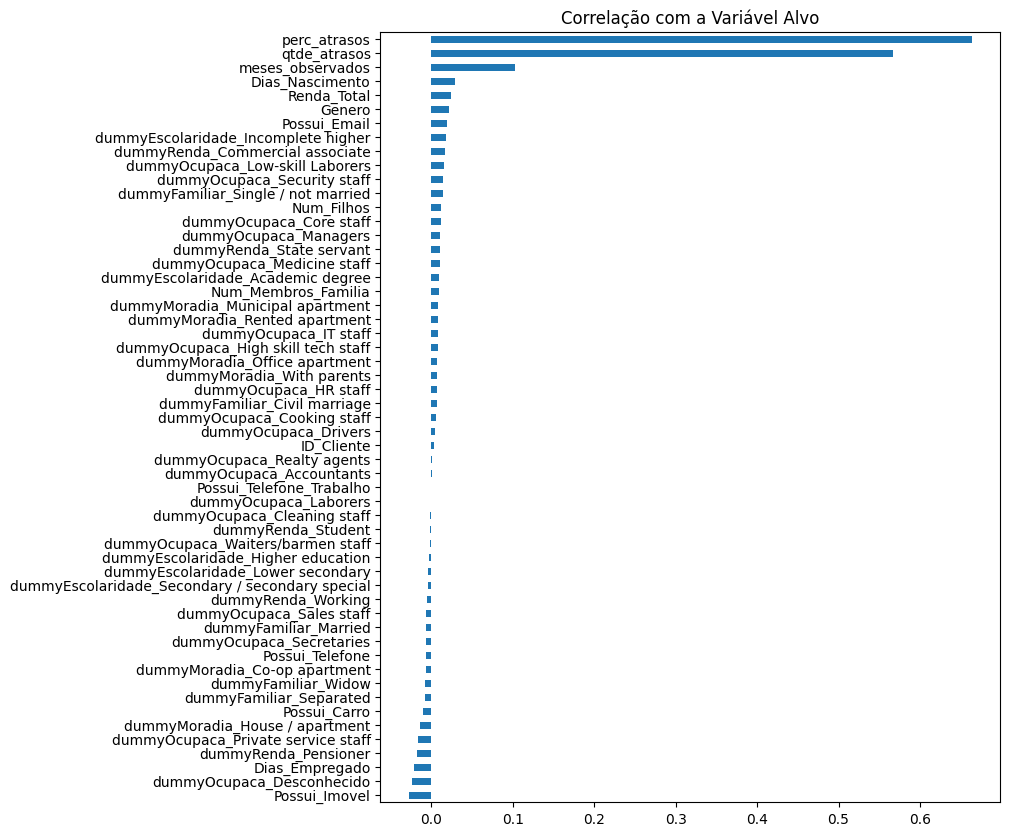

In [536]:
plt.figure(figsize=(8, 10))
corr_alvo.drop('target').sort_values().plot(kind='barh')
plt.title('Correlação com a Variável Alvo')
plt.show()

In [537]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

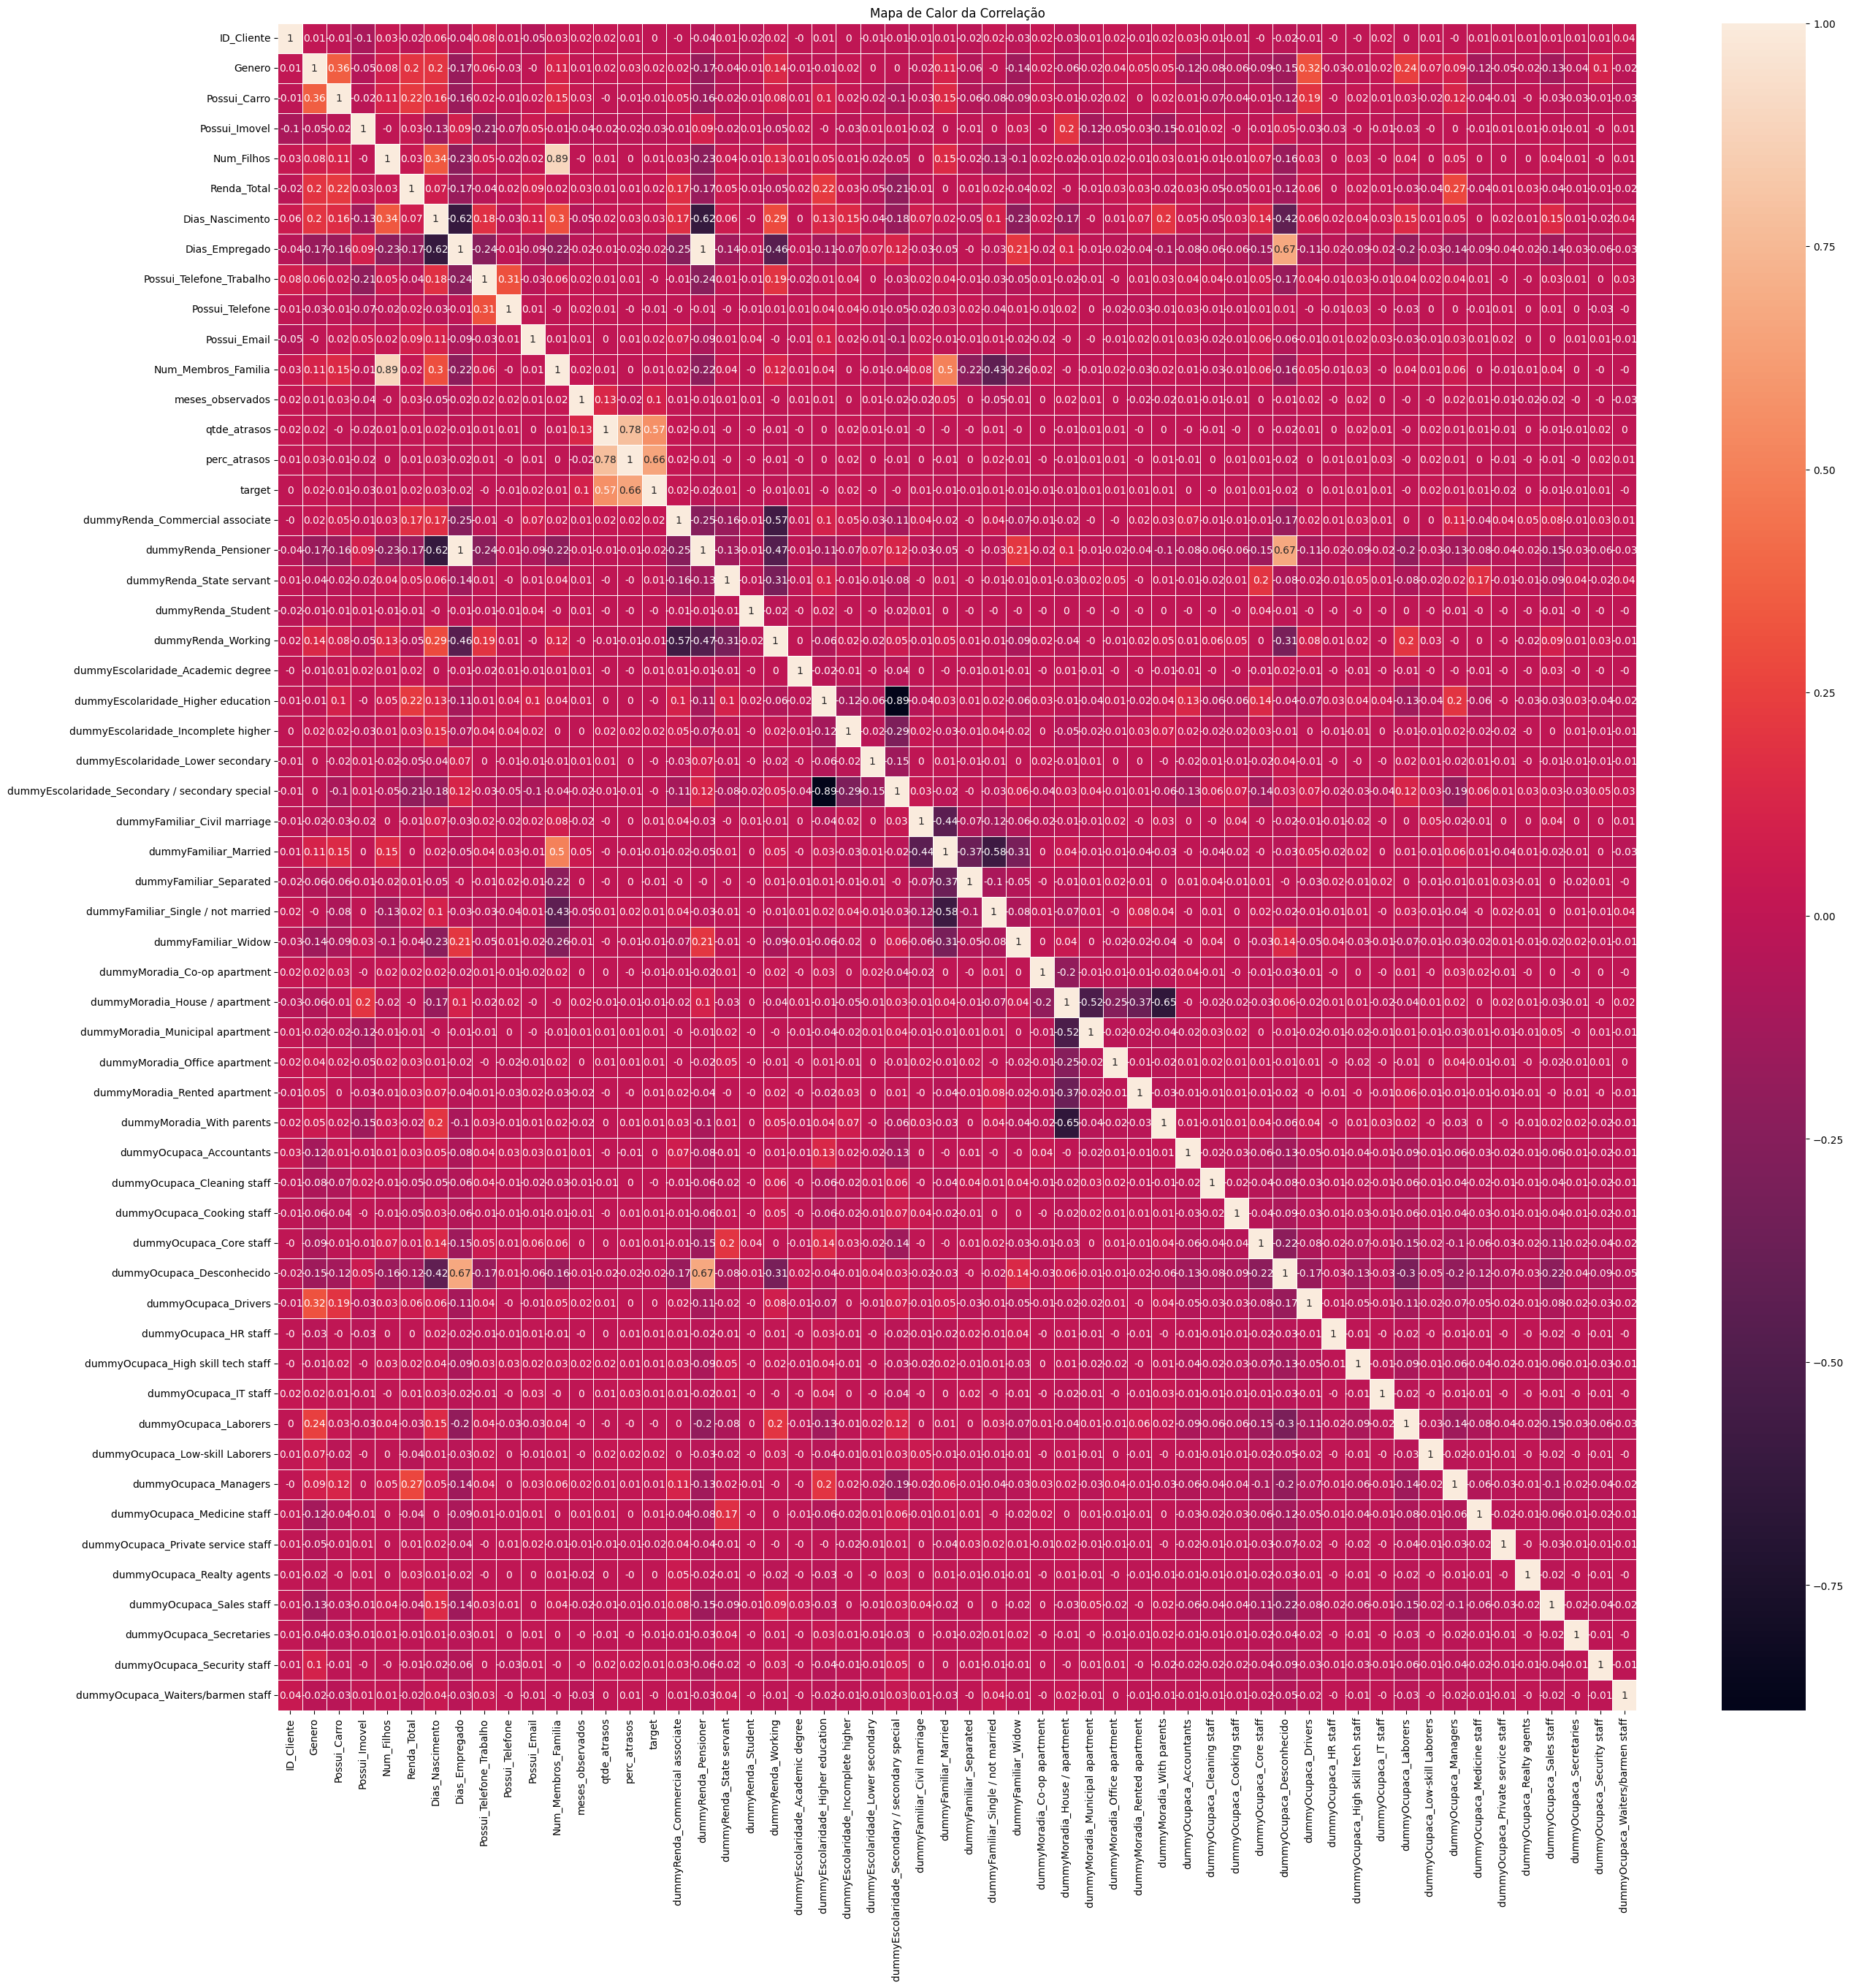

In [538]:
Corr_matriz = df.corr().round(2)

fig, ax = plt.subplots(figsize=(30, 30))
sb.heatmap(Corr_matriz, annot=True, linewidths=0.5, ax=ax)
plt.title('Mapa de Calor da Correlação')
plt.show()

In [539]:
corr_alvo = (df.corr(numeric_only=True)[['target']].sort_values(by='target', ascending=False).round(2))


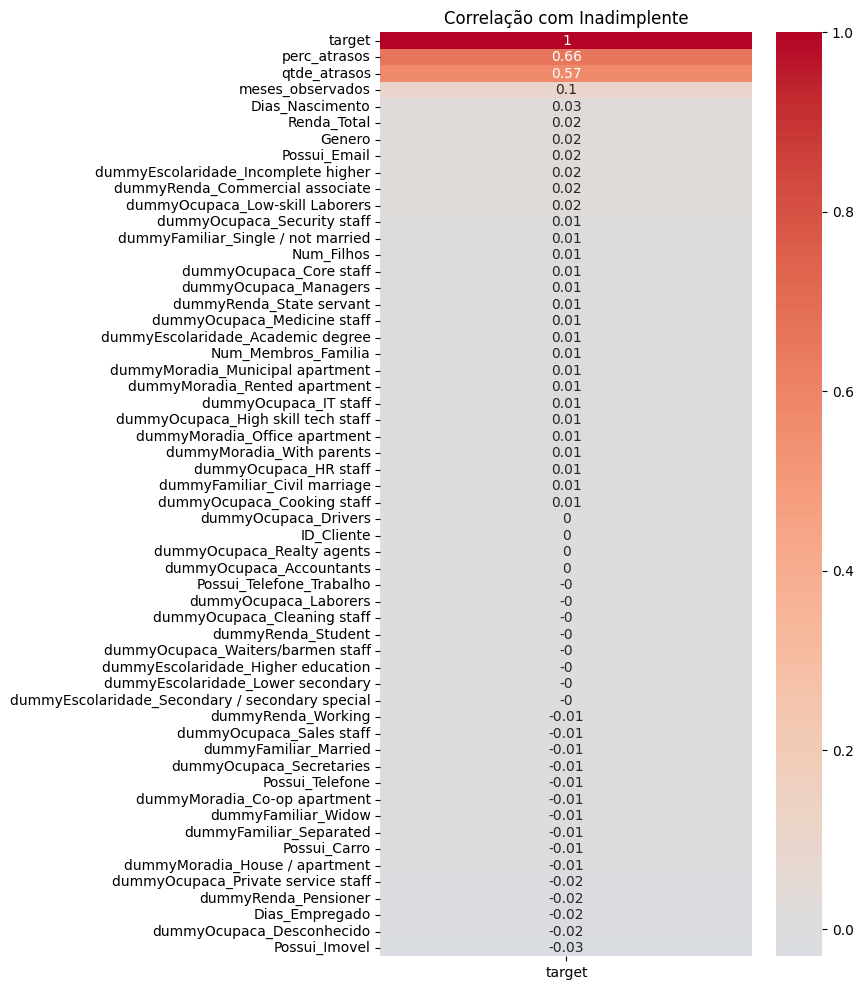

In [540]:
plt.figure(figsize=(6, 12))
sb.heatmap(corr_alvo,annot=True,cmap='coolwarm',center=0)

plt.title('Correlação com Inadimplente')
plt.show()

*
*
*
*
*


 **correlação dos dados**


In [541]:
colunas_excluir = ['ID_Cliente', 'qtde_atrasos', 'perc_atrasos']
df_corrigido = df.drop(columns=colunas_excluir)

In [542]:
dr_corr = df_corrigido.corr()

In [543]:
dr_corr.shape

(53, 53)

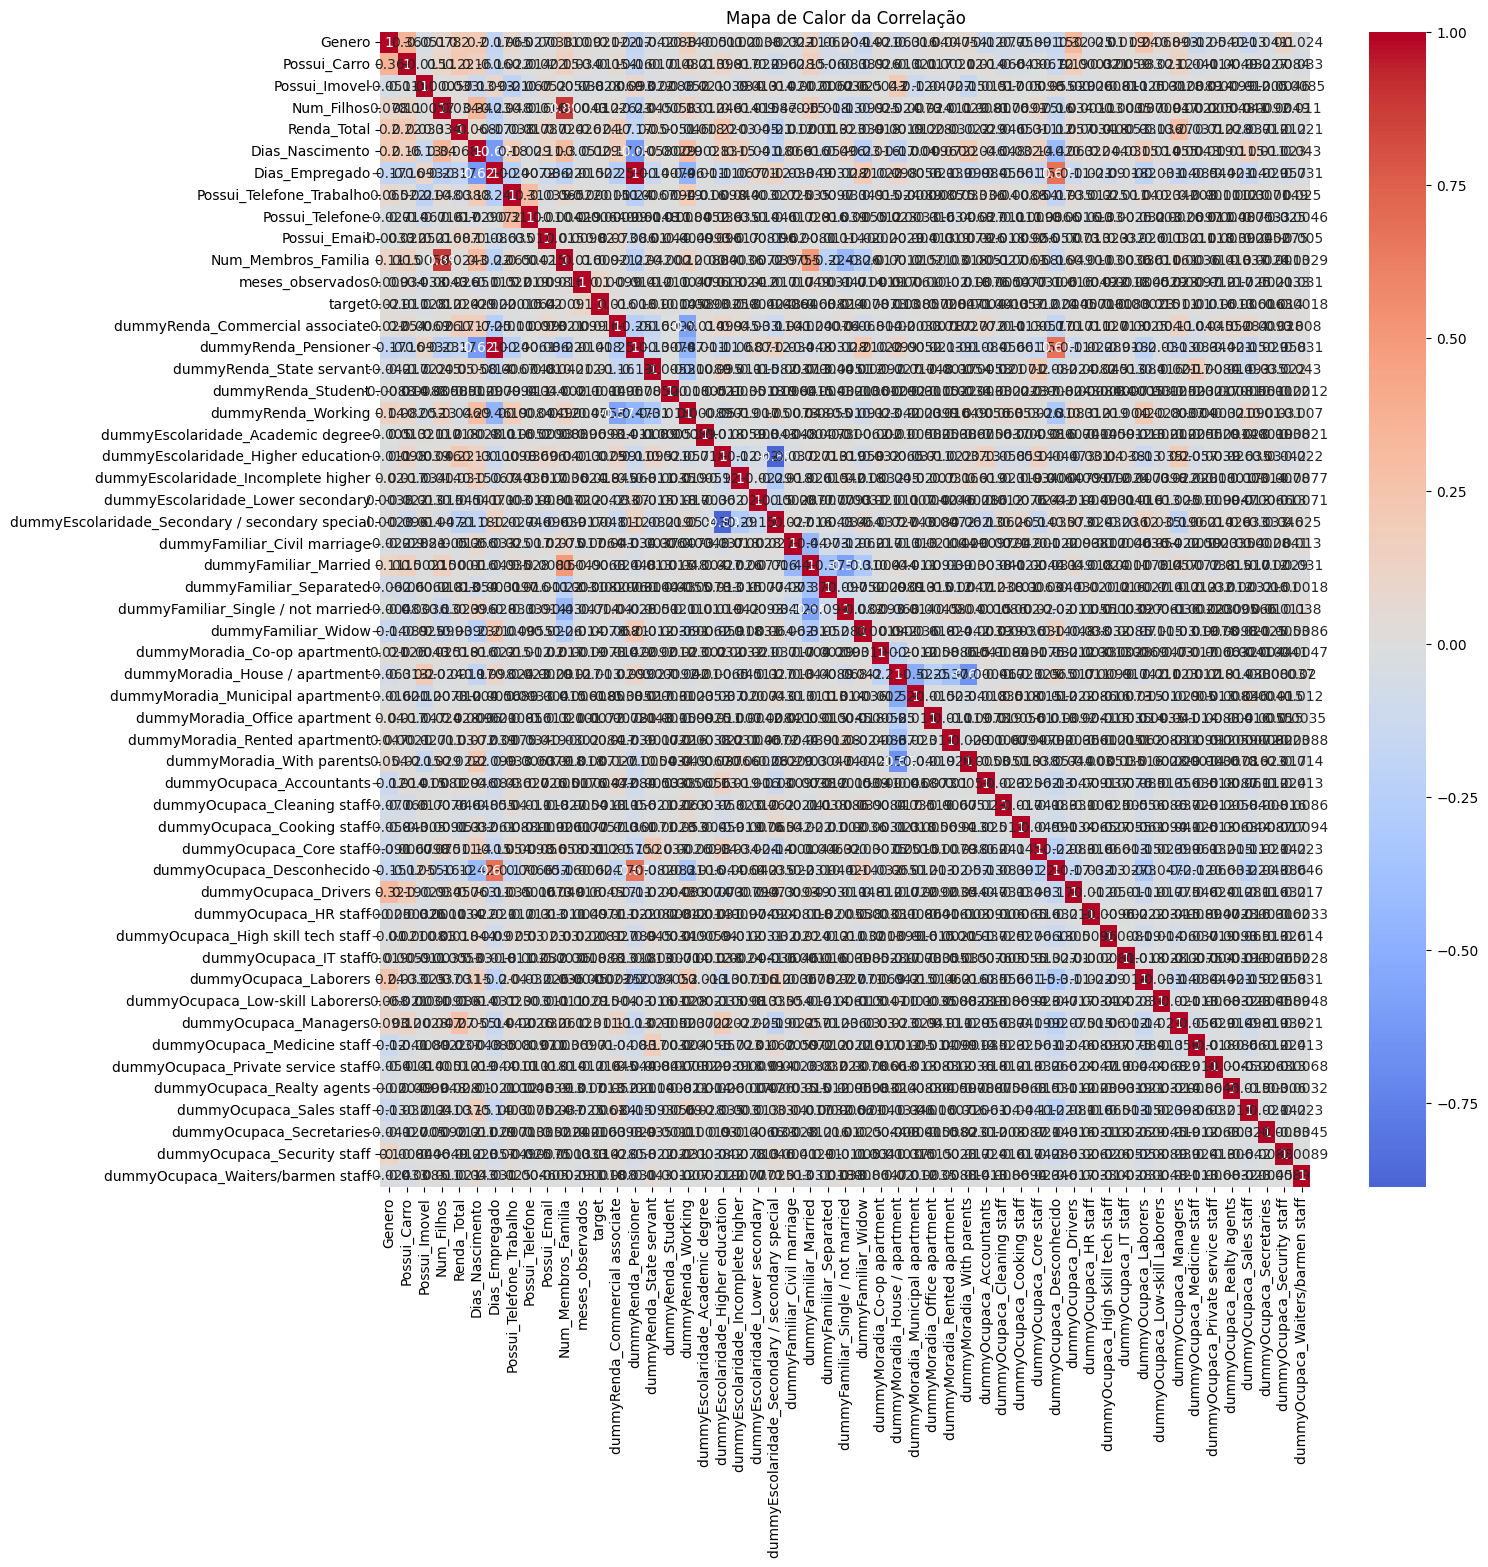

In [544]:
plt.figure(figsize=(15, 15))
sns.heatmap(dr_corr, annot=True, cmap='coolwarm', center=0)
plt.title('Mapa de Calor da Correlação')
plt.show()

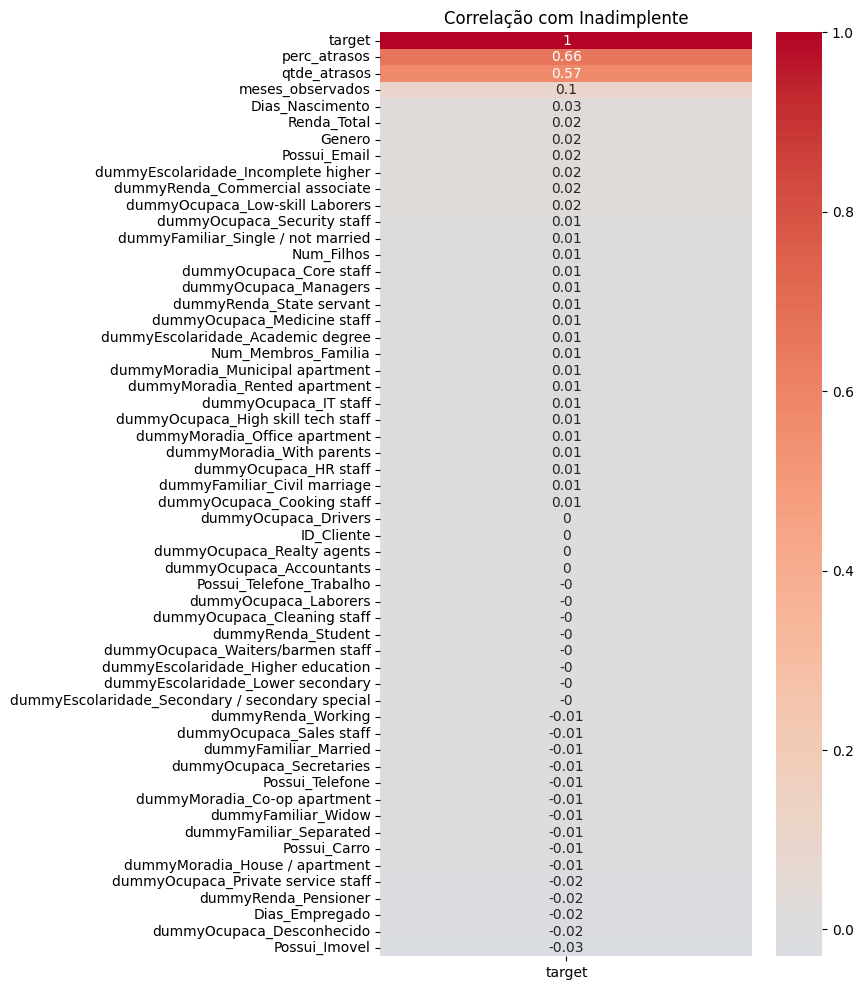

In [545]:
plt.figure(figsize=(6, 12))
sb.heatmap(corr_alvo,annot=True,cmap='coolwarm',center=0)

plt.title('Correlação com Inadimplente')
plt.show()

In [546]:
correlacao_target = df.drop(columns=['ID_Cliente','qtde_atrasos', 'perc_atrasos', 'meses_observados']).corr()['target'].drop('target').sort_values(ascending=False)

correlacao_target

,target
Dias_Nascimento,0.028943
Renda_Total,0.024202
Genero,0.021257
Possui_Email,0.019658
dummyEscolaridade_Incomplete higher,0.018118
dummyRenda_Commercial associate,0.016257
dummyOcupaca_Low-skill Laborers,0.015274
dummyOcupaca_Security staff,0.014359
dummyFamiliar_Single / not married,0.013716
Num_Filhos,0.011525


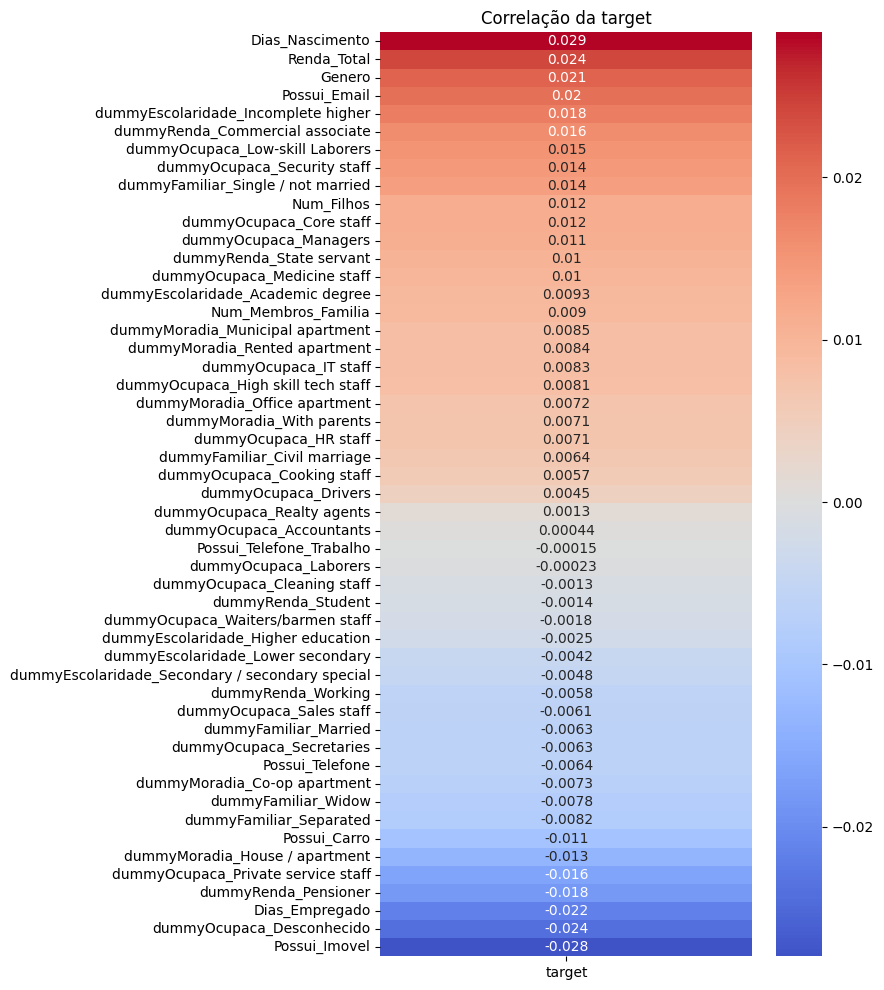

In [547]:
plt.figure(figsize=(6, 12))
sns.heatmap(correlacao_target.to_frame(), annot=True, cmap='coolwarm', center=0)

plt.title('Correlação da target')
plt.show()

In [548]:
top_correlacoes = correlacao_target.nlargest(10)

top_correlacoes

,target
Dias_Nascimento,0.028943
Renda_Total,0.024202
Genero,0.021257
Possui_Email,0.019658
dummyEscolaridade_Incomplete higher,0.018118
dummyRenda_Commercial associate,0.016257
dummyOcupaca_Low-skill Laborers,0.015274
dummyOcupaca_Security staff,0.014359
dummyFamiliar_Single / not married,0.013716
Num_Filhos,0.011525


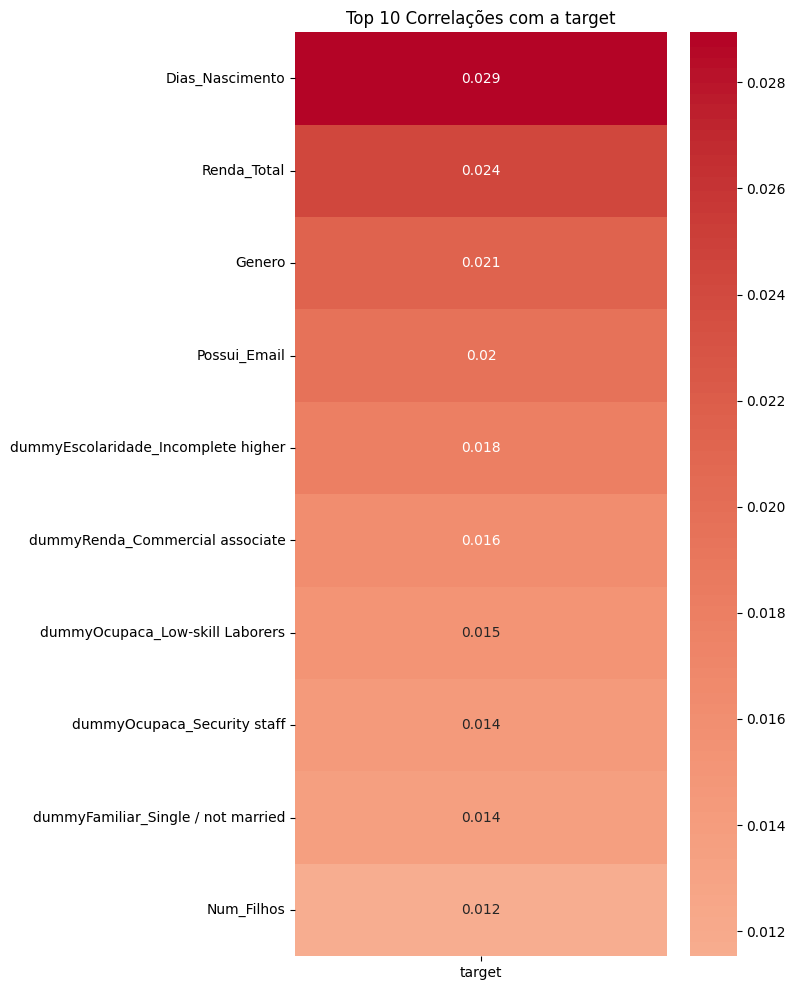

In [549]:
plt.figure(figsize=(6, 12))
sns.heatmap(top_correlacoes.loc[top_correlacoes.index].to_frame(), annot=True, cmap='coolwarm', center=0)

plt.title('Top 10 Correlações com a target')
plt.show()

*
*
*
*
*
*
*
*


### **Separação X/Y**

**y = a váriavel que queremos prever --> target**  ( 0 ou 1)

Bom pagador = 0 e mau pagador = 1

**X = variáveis características (Features) para fazer essa previsão**

As informações **qtde_atrasos** e **prec_atrasos** não serão usadas pois elas foram utilizadas para crias a variável target
*
*




In [550]:
df.head(3)

,ID_Cliente,Genero,Possui_Carro,Possui_Imovel,Num_Filhos,Renda_Total,Dias_Nascimento,Dias_Empregado,Possui_Telefone_Trabalho,Possui_Telefone,...,dummyOcupaca_Laborers,dummyOcupaca_Low-skill Laborers,dummyOcupaca_Managers,dummyOcupaca_Medicine staff,dummyOcupaca_Private service staff,dummyOcupaca_Realty agents,dummyOcupaca_Sales staff,dummyOcupaca_Secretaries,dummyOcupaca_Security staff,dummyOcupaca_Waiters/barmen staff
0,5008804,1,1,1,0,427500.0,-12005,-4542,1,0,...,0,0,0,0,0,0,0,0,0,0
1,5008805,1,1,1,0,427500.0,-12005,-4542,1,0,...,0,0,0,0,0,0,0,0,0,0
2,5008806,1,1,1,0,112500.0,-21474,-1134,0,0,...,0,0,0,0,0,0,0,0,1,0


In [551]:
df.shape

(36457, 56)

In [552]:
x = df.drop(columns=['ID_Cliente', 'qtde_atrasos', 'perc_atrasos', 'target', 'meses_observados'])
y = df['target']

In [553]:
df.head(3)

,ID_Cliente,Genero,Possui_Carro,Possui_Imovel,Num_Filhos,Renda_Total,Dias_Nascimento,Dias_Empregado,Possui_Telefone_Trabalho,Possui_Telefone,...,dummyOcupaca_Laborers,dummyOcupaca_Low-skill Laborers,dummyOcupaca_Managers,dummyOcupaca_Medicine staff,dummyOcupaca_Private service staff,dummyOcupaca_Realty agents,dummyOcupaca_Sales staff,dummyOcupaca_Secretaries,dummyOcupaca_Security staff,dummyOcupaca_Waiters/barmen staff
0,5008804,1,1,1,0,427500.0,-12005,-4542,1,0,...,0,0,0,0,0,0,0,0,0,0
1,5008805,1,1,1,0,427500.0,-12005,-4542,1,0,...,0,0,0,0,0,0,0,0,0,0
2,5008806,1,1,1,0,112500.0,-21474,-1134,0,0,...,0,0,0,0,0,0,0,0,1,0


SEPARANDO TREITO E TESTE (80% treito e 20% teste)

In [554]:
from sklearn.model_selection import train_test_split

In [555]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

In [556]:
x.shape

(36457, 51)

In [557]:
y.shape

(36457,)

In [558]:
x_train.shape

(29165, 51)

In [559]:
x_test.shape

(7292, 51)

In [560]:
y_train.shape

(29165,)

In [561]:
y_test.shape

(7292,)

# *

*
*
*
*
*
*
*
## **PADRONIZAÇÃO DOS DADOS (deixar na mesma escala)**

In [562]:
from sklearn.preprocessing import StandardScaler


In [563]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

In [564]:
x_train_scaled

array([[-0.70222092, -0.78136109,  0.69716492, ..., -0.06560799,
        -0.1281194 , -0.0701947 ],
       [ 1.42405328, -0.78136109,  0.69716492, ..., -0.06560799,
        -0.1281194 , -0.0701947 ],
       [-0.70222092, -0.78136109,  0.69716492, ..., -0.06560799,
        -0.1281194 , -0.0701947 ],
       ...,
       [-0.70222092, -0.78136109,  0.69716492, ..., -0.06560799,
        -0.1281194 , -0.0701947 ],
       [-0.70222092, -0.78136109,  0.69716492, ..., -0.06560799,
        -0.1281194 , -0.0701947 ],
       [-0.70222092, -0.78136109,  0.69716492, ..., -0.06560799,
        -0.1281194 , -0.0701947 ]])

In [565]:
x_train_scaled.shape

(29165, 51)

In [566]:
x_test_scaled = scaler.transform(x_test)

x_test_scaled

array([[ 1.42405328,  1.27981802,  0.69716492, ..., -0.06560799,
        -0.1281194 , -0.0701947 ],
       [-0.70222092, -0.78136109,  0.69716492, ..., -0.06560799,
        -0.1281194 , -0.0701947 ],
       [-0.70222092, -0.78136109, -1.43438083, ..., -0.06560799,
        -0.1281194 , -0.0701947 ],
       ...,
       [ 1.42405328,  1.27981802, -1.43438083, ..., -0.06560799,
        -0.1281194 , -0.0701947 ],
       [-0.70222092,  1.27981802,  0.69716492, ..., -0.06560799,
        -0.1281194 , -0.0701947 ],
       [-0.70222092,  1.27981802,  0.69716492, ..., -0.06560799,
        -0.1281194 , -0.0701947 ]])

In [567]:
x_test_scaled.shape

(7292, 51)

*
*
*
*
*
*
conferir as variáveis que estão no **x**






In [568]:
x.columns.tolist()

['Genero',
 'Possui_Carro',
 'Possui_Imovel',
 'Num_Filhos',
 'Renda_Total',
 'Dias_Nascimento',
 'Dias_Empregado',
 'Possui_Telefone_Trabalho',
 'Possui_Telefone',
 'Possui_Email',
 'Num_Membros_Familia',
 'dummyRenda_Commercial associate',
 'dummyRenda_Pensioner',
 'dummyRenda_State servant',
 'dummyRenda_Student',
 'dummyRenda_Working',
 'dummyEscolaridade_Academic degree',
 'dummyEscolaridade_Higher education',
 'dummyEscolaridade_Incomplete higher',
 'dummyEscolaridade_Lower secondary',
 'dummyEscolaridade_Secondary / secondary special',
 'dummyFamiliar_Civil marriage',
 'dummyFamiliar_Married',
 'dummyFamiliar_Separated',
 'dummyFamiliar_Single / not married',
 'dummyFamiliar_Widow',
 'dummyMoradia_Co-op apartment',
 'dummyMoradia_House / apartment',
 'dummyMoradia_Municipal apartment',
 'dummyMoradia_Office apartment',
 'dummyMoradia_Rented apartment',
 'dummyMoradia_With parents',
 'dummyOcupaca_Accountants',
 'dummyOcupaca_Cleaning staff',
 'dummyOcupaca_Cooking staff',
 'dumm

*

*

**dummy Renda**

In [569]:
[col for col in x.columns if 'dummyRenda' in col]

['dummyRenda_Commercial associate',
 'dummyRenda_Pensioner',
 'dummyRenda_State servant',
 'dummyRenda_Student',
 'dummyRenda_Working']

**dummy Escolaridade**

In [570]:
[col for col in x.columns if 'dummyEscolaridade' in col]

['dummyEscolaridade_Academic degree',
 'dummyEscolaridade_Higher education',
 'dummyEscolaridade_Incomplete higher',
 'dummyEscolaridade_Lower secondary',
 'dummyEscolaridade_Secondary / secondary special']

**dummy Família**

In [571]:
[col for col in x.columns if 'dummyFamiliar' in col]

['dummyFamiliar_Civil marriage',
 'dummyFamiliar_Married',
 'dummyFamiliar_Separated',
 'dummyFamiliar_Single / not married',
 'dummyFamiliar_Widow']

**dummy Moradia**

In [572]:
[col for col in x.columns if 'dummyMoradia' in col]

['dummyMoradia_Co-op apartment',
 'dummyMoradia_House / apartment',
 'dummyMoradia_Municipal apartment',
 'dummyMoradia_Office apartment',
 'dummyMoradia_Rented apartment',
 'dummyMoradia_With parents']

**dummy Ocupação**

In [573]:
[col for col in x.columns if 'dummyOcupaca'in col]

['dummyOcupaca_Accountants',
 'dummyOcupaca_Cleaning staff',
 'dummyOcupaca_Cooking staff',
 'dummyOcupaca_Core staff',
 'dummyOcupaca_Desconhecido',
 'dummyOcupaca_Drivers',
 'dummyOcupaca_HR staff',
 'dummyOcupaca_High skill tech staff',
 'dummyOcupaca_IT staff',
 'dummyOcupaca_Laborers',
 'dummyOcupaca_Low-skill Laborers',
 'dummyOcupaca_Managers',
 'dummyOcupaca_Medicine staff',
 'dummyOcupaca_Private service staff',
 'dummyOcupaca_Realty agents',
 'dummyOcupaca_Sales staff',
 'dummyOcupaca_Secretaries',
 'dummyOcupaca_Security staff',
 'dummyOcupaca_Waiters/barmen staff']

*
*
*
*
*
*

*
*
*



## Modelos

# **1- Radon Forest**

In [574]:
from sklearn.ensemble import RandomForestClassifier


In [575]:
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [576]:
modelo_rf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [577]:
y_pred_rf = modelo_rf.predict(x_test)


In [578]:
y_pred_rf

array([0, 0, 0, ..., 0, 0, 0])

## *Acurácia*

In [579]:
from sklearn.metrics import accuracy_score

In [580]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

accuracy_rf

0.8887822270981898

# **2 - KNN**

In [581]:
from sklearn.neighbors import KNeighborsClassifier

In [582]:
modelo_knn = KNeighborsClassifier(n_neighbors=5)

In [583]:
modelo_knn.fit(x_train_scaled, y_train)

KNeighborsClassifier()

In [584]:
y_pred_knn = modelo_knn.predict(x_test_scaled)

## *Acurária*

In [585]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)

accuracy_knn

0.8772627537026879

# **3 - SVM**

In [586]:
from sklearn.svm import SVC

In [587]:
modelo_svm = SVC(random_state=42)

modelo_svm.fit(x_train_scaled, y_train)

SVC(random_state=42)

In [588]:
y_pred_svm = modelo_svm.predict(x_test_scaled)

## *Acurácia*

In [589]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)

accuracy_svm

0.8824739440482721

# **4 - Regressão Logística**

In [590]:
from sklearn.linear_model import LogisticRegression

In [591]:
modelo_lr = LogisticRegression(random_state=42)

modelo_lr.fit(x_train_scaled, y_train)

LogisticRegression(random_state=42)

In [592]:
y_pred_lr = modelo_lr.predict(x_test_scaled)

## *Acurácia*

In [593]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

accuracy_lr

0.8827482172243555

*
*
*
*
*
*
*
## Matriz de Confusão

# Matriz RF

In [594]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

In [595]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

cm_rf

array([[6192,  242],
       [ 569,  289]])

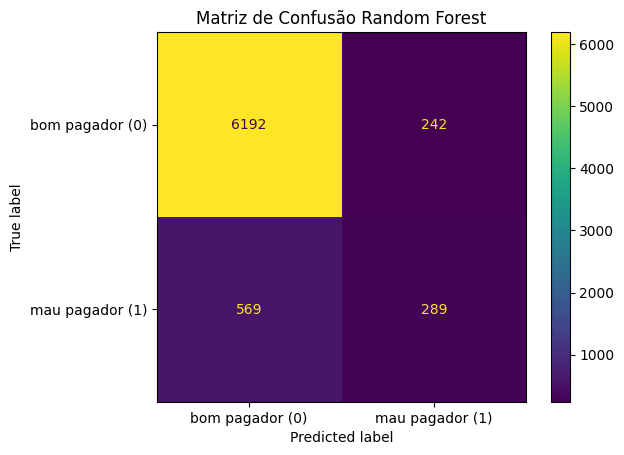

In [596]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels = ['bom pagador (0)', 'mau pagador (1)'])

disp.plot()
plt.title('Matriz de Confusão Random Forest')
plt.show()

## Matriz KNN

In [597]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

cm_knn

array([[6214,  220],
       [ 675,  183]])

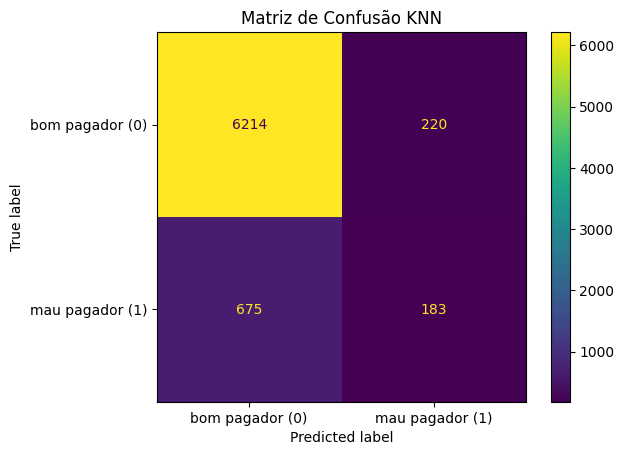

In [598]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels = ['bom pagador (0)', 'mau pagador (1)'])

disp.plot()
plt.title('Matriz de Confusão KNN')
plt.show()

# Matriz SVM

In [599]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

cm_svm

array([[6426,    8],
       [ 849,    9]])

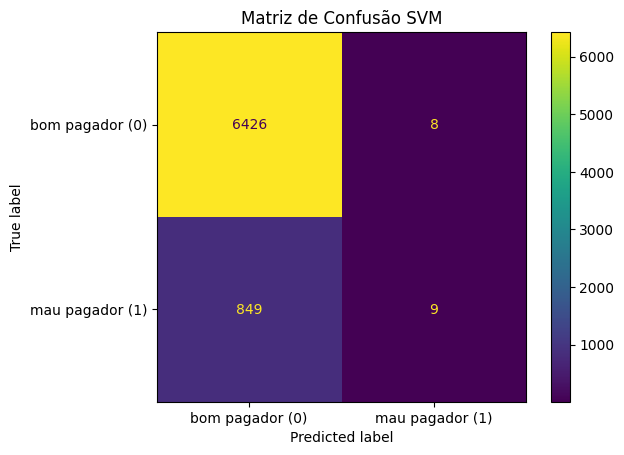

In [600]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels = ['bom pagador (0)', 'mau pagador (1)'])

disp.plot()
plt.title('Matriz de Confusão SVM')
plt.show()

# Matriz RL

In [601]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

cm_lr

array([[6434,    0],
       [ 855,    3]])

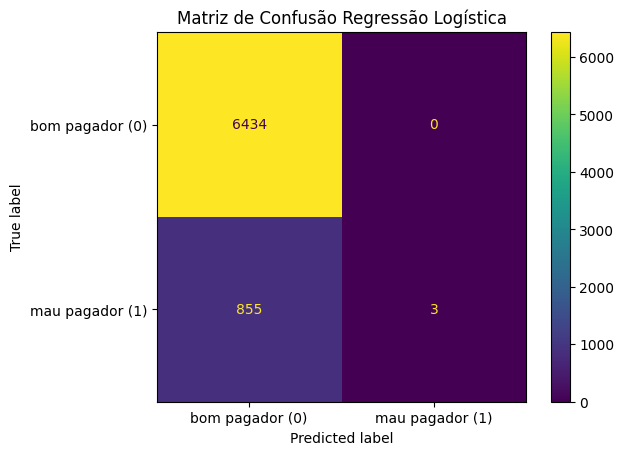

In [602]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels = ['bom pagador (0)', 'mau pagador (1)'])

disp.plot()
plt.title('Matriz de Confusão Regressão Logística')
plt.show()

*
*
*
*
*
*




# Avaliação de cada modelo:

In [603]:
from sklearn.metrics import classification_report

In [604]:
print("Randon Forest")
print(classification_report(y_test, y_pred_rf))

print("KNN")
print(classification_report(y_test, y_pred_knn))

print("SVM")
print(classification_report(y_test, y_pred_svm))

print("Regressão Logística")
print(classification_report(y_test, y_pred_lr))

Randon Forest
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      6434
           1       0.54      0.34      0.42       858

    accuracy                           0.89      7292
   macro avg       0.73      0.65      0.68      7292
weighted avg       0.87      0.89      0.88      7292

KNN
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      6434
           1       0.45      0.21      0.29       858

    accuracy                           0.88      7292
   macro avg       0.68      0.59      0.61      7292
weighted avg       0.85      0.88      0.86      7292

SVM
              precision    recall  f1-score   support

           0       0.88      1.00      0.94      6434
           1       0.53      0.01      0.02       858

    accuracy                           0.88      7292
   macro avg       0.71      0.50      0.48      7292
weighted avg       0.84      0.88      0.83      729